# LOCAL BOUNDED VALIDATION COPY

Drive and install cells are replaced. Evaluation uses deliberately near-cap fixtures, not complete-game strength tests. Notebook 02 skips training. Temporary paths in outputs are not the production Colab paths.

# No RL 04 - Held-Out Evaluation and Selection

Freeze the selected variant, then measure it on the held-out suite. No RL completion files are read. This records a selection, not an assertion that the agent is strong or accepted by the platform.

## Mount Google Drive

In [1]:
print("Local validation only: no Drive mount.")

Local validation only: no Drive mount.


## Project Setup

Uses `configs/no_rl.yaml`. No league, self-play, PPO, or DQN is run. Colab's installed PyTorch is preserved.

In [2]:
from pathlib import Path
import sys, subprocess
from IPython.display import display
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
def show_figure(fig):
    display(fig)
    plt.close(fig)
PROJECT_ROOT = Path('/mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv')
sys.path.insert(0, str(PROJECT_ROOT))
from chess_rl.non_rl import load_no_rl_config
from chess_rl.reproducibility import read_json, sha256
cfg = load_no_rl_config(PROJECT_ROOT)
cfg["non_rl"]["variant"] = "classical"
cfg["run_id"] = "no_rl_local_fixture"
cfg["evaluation"].update(development_games=2, heldout_games=2, bootstrap_samples=100)
cfg["non_rl"]["tuning"].update(trials=1, games_per_trial=2, confirmation_games=2)
print("LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.")
print("No Drive mount, no training, no export/compliance execution.")
from chess_rl import plots
original_plot_matches = plots.plot_matches
def fixture_plot(root, run_id, summaries, name):
    fig = original_plot_matches(root, run_id, summaries, name)
    fig.axes[0].set_title('LOCAL FIXTURE ONLY: one ply before the game cap')
    fig.axes[0].set_xlabel('Score (%); intervals unavailable with one opening pair')
    plots.save(fig, root, run_id, name)
    return fig
plots.plot_matches = fixture_plot


LOCAL FIXTURE: CPU, one ply before game cap, two games per opponent.
No Drive mount, no training, no export/compliance execution.


## Confirm the Candidate

Complete development experiments before this step. The lock covers source hashes, search settings, and any supervised checkpoint. Do not reuse this held-out suite as fresh evidence after tuning to its results.

In [3]:
from chess_rl.non_rl import candidate_spec
spec = candidate_spec(PROJECT_ROOT, cfg)
print("Variant:", spec["variant"])
print("Checkpoint:", spec["checkpoint"] or "None: classical, no training")
print("Held-out games per opponent:", cfg["evaluation"]["heldout_games"])

Variant: classical
Checkpoint: None: classical, no training
Held-out games per opponent: 2


## Run or Resume Held-Out Games

The candidate is locked before games begin. All opponents use the same reserved fixtures and clocks. The selected run may be exported even if its playing strength is poor, but final runtime checks can still fail.

In [4]:
from chess_rl.non_rl import evaluate_and_freeze_no_rl
selection = evaluate_and_freeze_no_rl(PROJECT_ROOT, cfg)
print("Selection:", PROJECT_ROOT / "results" / cfg["run_id"] / "no_rl/final_selection.json")
print("Training status:", selection["training_status"])

no-rl-heldout-greedy: 1/2, draw, ply_cap


no-rl-heldout-greedy: 2/2, draw, ply_cap


no-rl-heldout-minimax: 1/2, draw, ply_cap


no-rl-heldout-minimax: 2/2, draw, ply_cap


no-rl-heldout-original_classical: 1/2, draw, ply_cap


no-rl-heldout-original_classical: 2/2, draw, ply_cap


Selection: /mnt/d/Benjamin Data/Introduction to AI/Chess Agent Competition/colab_chess_research/results/no_rl_notebook_validation/fixture-pp15y2lv/results/no_rl_local_fixture/no_rl/final_selection.json
Training status: not_applicable


## Read the Results

These are observed scores, not guaranteed future performance. Colab does not reproduce the platform's CPU speed, isolation, or hidden openings. Final packaging/compliance is exclusively in no-RL notebook 05.

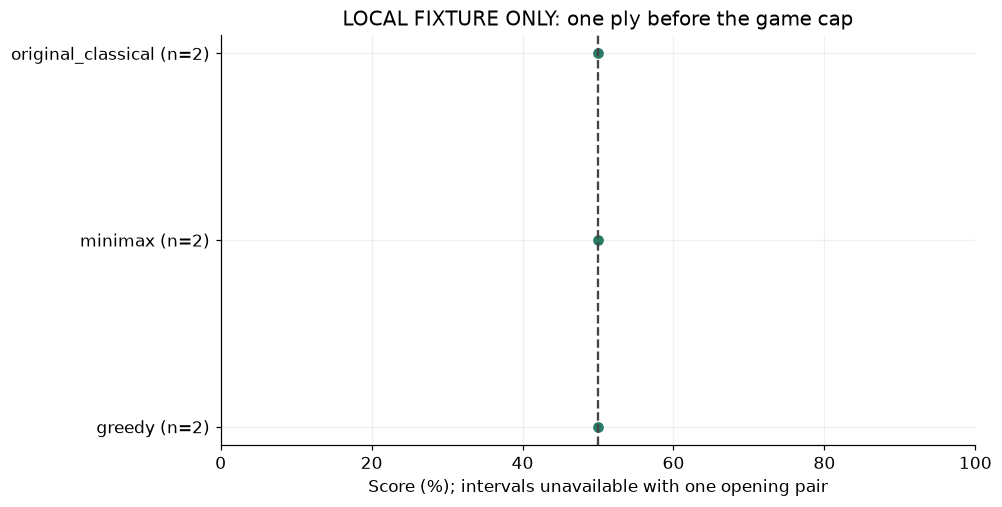

In [5]:
from chess_rl.plots import plot_matches
show_figure(plot_matches(PROJECT_ROOT, cfg["run_id"], selection["heldout"], "no_rl_heldout"))